# Faketucky Classification — Original Data Baseline

This notebook accompanies the IEEE IRI 2026 paper *"A Privacy-Preserving Framework
Using Remote Data Science for Inter-Institutional Student Retention Prediction"*
([repo](https://github.com/jtfields/NAIRR240195-Privacy-Preserving-Machine-Learning)).

## Purpose

Trains and evaluates a student-retention classifier on the **original (non-synthetic)**
Faketucky dataset. This serves as the **baseline** against which the SDV-based
synthetic-data results in `FaketuckySDV.ipynb` are compared (see Table VI in the paper:
mean degradation of 34.4% when SDV synthetic data is used in place of the original).

## Dataset

**Faketucky** — a publicly available synthetic college-going dataset (~85,000 records)
published by OpenSDP at the Center for Education Policy Research, Harvard University.
Available at https://github.com/OpenSDP/faketucky under the MIT License.

The prediction target is `enroll_yr2_any` (whether a student remained enrolled into
their second year), restricted to students who attended college in year 1.

## Pipeline

1. Load and inspect data
2. Handle missing values in target columns
3. Filter to year-1 college attendees
4. Drop leakage-prone columns
5. Stratified 80/20 train/test split
6. Median / most-frequent imputation
7. Ordinal encoding of categorical features
8. SMOTE class balancing on the training set
9. XGBoost classifier with 5-fold cross-validation
10. Evaluation: confusion matrix, ROC, PR curves
11. SHAP feature-importance analysis
12. Classification threshold optimization
13. Risk-group assignment (High / Medium / Low)
14. Persist model and predictions

## Requirements

- Python 3.10+ (developed under 3.13.0 in Colab)
- `pandas`, `numpy`, `scikit-learn`, `imbalanced-learn`, `xgboost`, `shap`,
  `matplotlib`, `seaborn`
- The Faketucky `.dta` file uploaded via `files.upload()` in the cell below

## Note on Faketucky vs. private institutional data

The paper reports results on both Faketucky and a private institutional dataset
(Concordia 2021 cohort, N=720). This notebook covers only the Faketucky pipeline;
the private dataset is not in this repository and is executed on the high-side
server in the Remote Data Science workflow.

In [56]:
pip install imblearn

importing the required libraries

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
import warnings
from google.colab import files
#warnings.filterwarnings('ignore')


We import NumPy for random number generation, set a fixed seed (42) to ensure reproducibility, and initialize the random number generator to produce consistent results across different runs of the code.


In [58]:

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

Load the Stata data file from the specified path, read it into a pandas DataFrame, and print the number of rows and columns in the dataset.


In [59]:
# print("Loading data...")
# data_path = "file path"
# data = pd.read_stata(data_path)
# print(f"Data loaded: {data.shape[0]} rows, {data.shape[1]} columns")

# Load packages and import Faketucky dataset
import pandas as pd


# Upload faketucky.dta from your local machine
# (returns a dict; we discard the return value and read from disk instead)
files.upload()

print("Loading data...")
data = pd.read_stata("faketucky.dta")
print(f"Data loaded: {data.shape[0]} rows, {data.shape[1]} columns")

Saving faketucky.dta to faketucky (1).dta
Loading data...
Data loaded: 111991 rows, 68 columns


Display the first few rows

In [60]:

data.head()

,sid,sid_type,first_coop_code,first_dist_code,first_hs_code,first_dist_name,first_hs_name,first_hs_alt,first_hs_urbanicity,chrt_ninth,...,ihe_retention_lt_4_yr_part_time,ihe_federal_loan_rate,ihe_share_25_older,ihe_med_debt_completers_all,ihe_med_debt_completers_pmts,ihe_ihe_repay_3_yr_all,ihe_rate_4_yr,ihe_rate_lt_4_yr,ihe_med_earn_10_yrs_after,ihe_pct_earn_gt_25k_6_yrs_after
0,10,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1622,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1877,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2009,...,0.4522,0.2661,0.3929,9740.0,108.133967,0.556974,NaN,0.398137,25000.0,0.44169
3,1941,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2009,...,0.4522,0.2661,0.3929,9740.0,108.133967,0.556974,NaN,0.398137,25000.0,0.44169
4,2405,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Display the distribution of the target variable 'enroll_yr2_any' and calculate the retention rate as the mean percentage of students retained.


In [61]:
print("Target variable (enroll_yr2_any) distribution:")
print(data['enroll_yr2_any'].value_counts())
print(f"Retention rate: {data['enroll_yr2_any'].mean() * 100:.2f}%")

Target variable (enroll_yr2_any) distribution:
enroll_yr2_any
0.0    66384
1.0    18776
Name: count, dtype: int64
Retention rate: 22.05%


Print the count of each data type in the dataset to understand the distribution of numerical and categorical variables.


In [62]:
print("Data types:")
print(data.dtypes.value_counts())

Data types:
float64     40
int8        13
object       6
int16        4
int32        1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


Identify and display columns with missing values in the dataset by summing the null values in each column.


In [63]:
missing_data = data.isnull().sum()
print("Columns with missing values:")
print(missing_data[missing_data > 0])

Columns with missing values:
first_hs_urbanicity                   697
male                                   19
frpl_ever_in_hs                      1415
scale_score_6_math                  69447
scale_score_6_read                  69447
scale_score_8_math                  19485
scale_score_8_read                  19758
pct_absent_in_hs                      222
pct_excused_in_hs                     224
avg_gpa_hs                           3746
scale_score_11_eng                  25854
scale_score_11_math                 25870
scale_score_11_read                 25893
scale_score_11_comp                 25909
chrt_grad                           26831
enroll_yr1_any                      26831
enroll_yr1_2yr                      26831
enroll_yr1_4yr                      26831
enroll_yr2_any                      26831
ihe_code_yr1                        67549
ihe_degrees_awarded_predominant     70277
ihe_degrees_awarded_highest         70277
ihe_act_25th_pctl_cumulative        85881
ihe_a

Check and display the number of missing (NaN) values in the target variables 'enroll_yr2_any' and 'enroll_yr1_any'.


In [64]:

print(f"NaN values in enroll_yr2_any: {data['enroll_yr2_any'].isna().sum()}")
print(f"NaN values in enroll_yr1_any: {data['enroll_yr1_any'].isna().sum()}")

NaN values in enroll_yr2_any: 26831
NaN values in enroll_yr1_any: 26831


Remove rows with missing values in the target columns 'enroll_yr2_any' and 'enroll_yr1_any' and print a message after removal.


In [65]:

if data['enroll_yr2_any'].isna().sum() > 0 or data['enroll_yr1_any'].isna().sum() > 0:
    print("Handling NaN values in target columns...")
    data = data.dropna(subset=['enroll_yr2_any', 'enroll_yr1_any']).copy()
    print(f"Removed rows with NaN values in target columns")

Handling NaN values in target columns...
Removed rows with NaN values in target columns


 Filter the dataset to include only students who attended college in year 1 ('enroll_yr1_any' = 1) and print the number of students before and after filtering.


In [66]:
# Filter for only students who attended college in year 1
print("\nFiltering for students who attended college in year 1 (enroll_yr1_any = 1)")
print(f"Before filtering: {data.shape[0]} students")
data = data[data['enroll_yr1_any'] == 1].copy()
print(f"After filtering: {data.shape[0]} students")


Filtering for students who attended college in year 1 (enroll_yr1_any = 1)
Before filtering: 85160 students
After filtering: 44442 students


Calculate and display the retention rate among college attendees and show the distribution of the 'enroll_yr2_any' variable.


In [67]:
print(f"\nRetention rate among college attendees: {data['enroll_yr2_any'].mean() * 100:.2f}%")
print("Distribution of enroll_yr2_any among college attendees:")
print(data['enroll_yr2_any'].value_counts())



Retention rate among college attendees: 37.55%
Distribution of enroll_yr2_any among college attendees:
enroll_yr2_any
0.0    27753
1.0    16689
Name: count, dtype: int64


Define a list of columns to drop that could cause data leakage by including future outcomes or direct identifiers.


In [68]:

columns_to_drop = [
    'sid', 'sid_type',                              # Identifiers
    'dropout', 'still_enrolled', 'ontime_grad',     # Future outcomes
    'transferout', 'hs_diploma',                    # Future outcomes
    'enroll_yr1_2yr', 'enroll_yr1_4yr',             # Derivatives of enrollment
    'ihe_code_yr1', 'ihe_name_yr1',                 # Direct identifiers of where they enrolled
    'last_acadyr_observed',                         # Future information
]

Drop the columns that exist in the dataset to avoid data leakage and print the number of removed columns and remaining columns.


In [69]:

columns_to_drop = [col for col in columns_to_drop if col in data.columns]
data_cleaned = data.drop(columns=columns_to_drop)
print(f"Removed {len(columns_to_drop)} columns that could cause data leakage")
print(f"Remaining columns: {data_cleaned.shape[1]}")

Removed 12 columns that could cause data leakage
Remaining columns: 56


Split the dataset into features (X) and target variable (y), where 'enroll_yr2_any' is the target and the rest are features.


In [70]:

X = data_cleaned.drop('enroll_yr2_any', axis=1)
y = data_cleaned['enroll_yr2_any']


Split the data into training and test sets (80/20 split) while ensuring the target variable is stratified, and print the number of samples in each set.


In [71]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 35553 samples
Test set: 8889 samples


Display the normalized distribution of the target variable in both the training and test sets to check for class balance.


In [72]:
print("Target distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nTarget distribution in test set:")
print(y_test.value_counts(normalize=True))

Target distribution in training set:
enroll_yr2_any
0.0    0.624476
1.0    0.375524
Name: proportion, dtype: float64

Target distribution in test set:
enroll_yr2_any
0.0    0.62448
1.0    0.37552
Name: proportion, dtype: float64


Identify and count the numeric and categorical features in the training set based on their data types.


In [73]:

numeric_cols = X_train.select_dtypes(include=['int64', 'int32', 'int16', 'int8', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numeric features: 47
Categorical features: 8


Use median imputation to fill missing values in numeric features for both the training and test sets.


In [74]:

numeric_imputer = SimpleImputer(strategy='median')
X_train[numeric_cols] = numeric_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = numeric_imputer.transform(X_test[numeric_cols])

 Use most frequent imputation to fill missing values in categorical features for both the training and test sets, applying the imputer column by column.


In [75]:
for col in categorical_cols:
    # Create a new imputer for each column
    cat_imputer = SimpleImputer(strategy='most_frequent')

    # Reshape the result to ensure we get a 1D array
    imputed_values = cat_imputer.fit_transform(X_train[[col]])
    X_train[col] = imputed_values.ravel()  # Flatten the array to 1D

    # Do the same for test data
    imputed_values_test = cat_imputer.transform(X_test[[col]])
    X_test[col] = imputed_values_test.ravel()

Encode categorical features using Ordinal Encoding, with error handling for unknown categories; if encoding fails, use factorization as a fallback.


In [76]:
for col in categorical_cols:
    # Handle potential errors with encoding
    try:
        # Create a new encoder for each column
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

        # Reshape the result to ensure we get a 1D array
        encoded_values = encoder.fit_transform(X_train[[col]])
        X_train[col] = encoded_values.ravel()

        # Apply same transformation to test data
        encoded_values_test = encoder.transform(X_test[[col]])
        X_test[col] = encoded_values_test.ravel()
    except Exception as e:
        print(f"Error encoding column {col}: {e}")
        # If encoding fails, we could use factorize as a fallback
        X_train[col], _ = pd.factorize(X_train[col])
        X_test[col], _ = pd.factorize(X_test[col])

Check and print the total number of missing values in the training and test sets after imputation to ensure all missing values are handled.


In [77]:

print("Missing values after imputation:")
print(f"Training set: {X_train.isnull().sum().sum()}")
print(f"Test set: {X_test.isnull().sum().sum()}")

Missing values after imputation:
Training set: 0
Test set: 0


Display the class distribution before and after applying SMOTE to balance the classes in the training set by generating synthetic samples.


In [78]:
print("Class distribution before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE to balance classes
smote = SMOTE(random_state=SEED)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

Class distribution before SMOTE:
enroll_yr2_any
0.0    22202
1.0    13351
Name: count, dtype: int64

Class distribution after SMOTE:
enroll_yr2_any
1.0    22202
0.0    22202
Name: count, dtype: int64


 Create a side-by-side plot to visualize and compare the class distribution before and after applying SMOTE to balance the dataset.


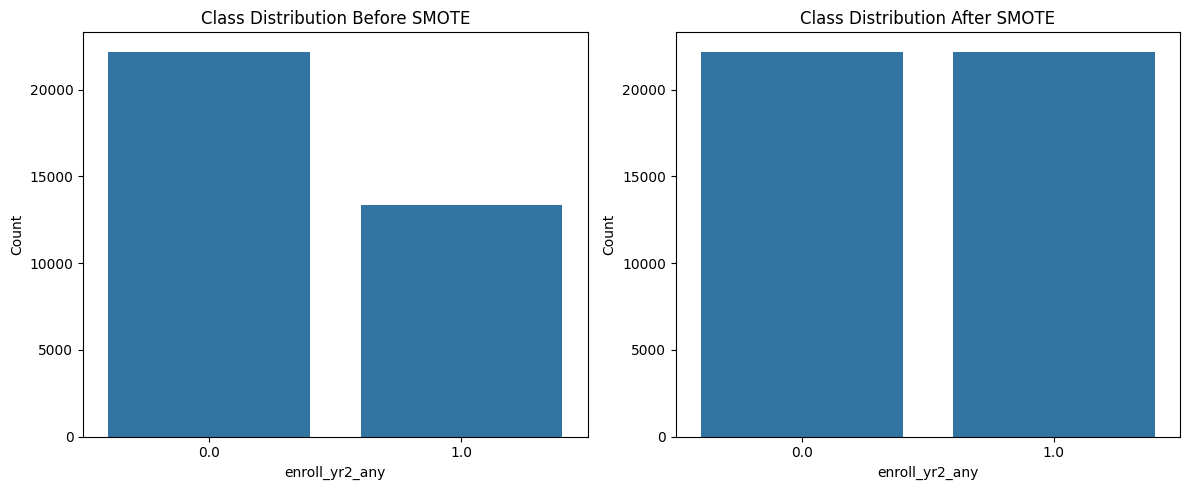

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
sns.countplot(x=y_train, ax=ax[0])
ax[0].set_title('Class Distribution Before SMOTE')
ax[0].set_xlabel('enroll_yr2_any')
ax[0].set_ylabel('Count')

# After SMOTE
sns.countplot(x=y_train_balanced, ax=ax[1])
ax[1].set_title('Class Distribution After SMOTE')
ax[1].set_xlabel('enroll_yr2_any')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Initialize the XGBoost classifier model with specified hyperparameters for binary classification, including regularization and balanced class weights.


In [80]:
model = XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.1,
    max_depth=5,
    n_estimators=100,
    reg_lambda=1.0,  # L2 regularization
    reg_alpha=0.1,   # L1 regularization
    scale_pos_weight=1,  # Already balanced with SMOTE
    random_state=SEED
)


Perform 5-fold cross-validation on the balanced training set to evaluate the model's accuracy and print the mean and standard deviation of the results.


In [81]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced,
                           cv=cv, scoring='accuracy')

print(f"Cross-validation accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Cross-validation accuracy: 0.8984 ± 0.0030


Train the final XGBoost model on the balanced training set (after SMOTE) using the entire dataset.


In [82]:

model.fit(X_train_balanced, y_train_balanced)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

Use the trained model to make predictions on the test set, including the probability of class 1 (retention).


In [83]:

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1 (retention)

Calculate and print key classification metrics (accuracy, precision, recall, and F1 score) to evaluate the model's performance on the test set.


In [84]:

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8755
Precision: 0.7721
Recall: 0.9482
F1 Score: 0.8511


Generate and print the classification report, showing precision, recall, F1 score, and support for each class in the test set.


In [85]:

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.83      0.89      5551
         1.0       0.77      0.95      0.85      3338

    accuracy                           0.88      8889
   macro avg       0.87      0.89      0.87      8889
weighted avg       0.89      0.88      0.88      8889



Plot the confusion matrix to visualize the true positives, false positives, true negatives, and false negatives in the model's predictions.


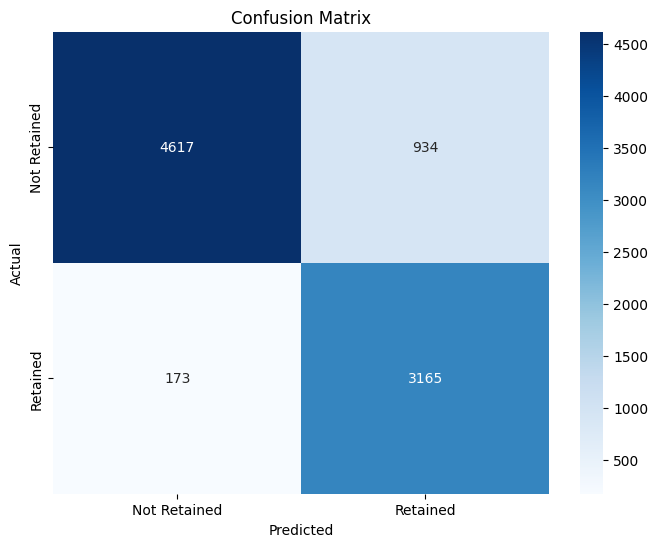

In [86]:

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Not Retained', 'Retained'],
           yticklabels=['Not Retained', 'Retained'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Plot the Receiver Operating Characteristic (ROC) curve and calculate the AUC (Area Under the Curve) to evaluate the model's ability to distinguish between classes.


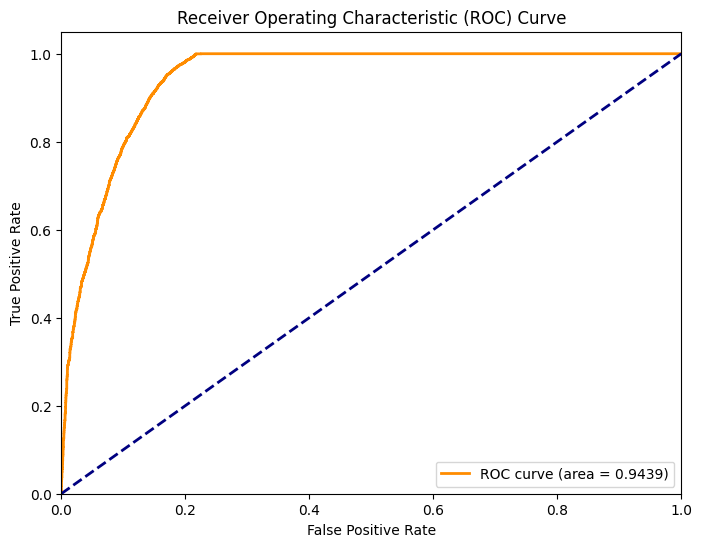

In [87]:

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Plot the Precision-Recall curve and calculate the AUC (Area Under the Curve) to assess the model's performance with respect to precision and recall.


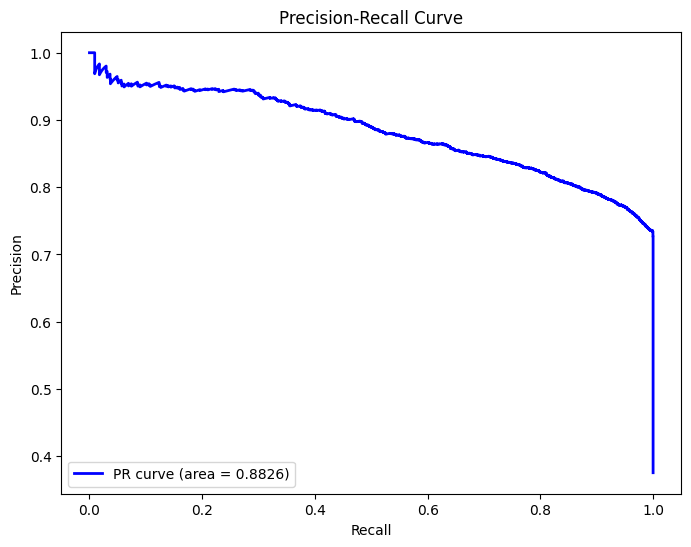

In [88]:

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall_curve, precision_curve)

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Calculate and display the importance of each feature based on the trained model, sorting them in descending order to identify the most influential features.


In [89]:

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

Visualize the top 20 most important features based on the model's feature importance using a horizontal bar plot.


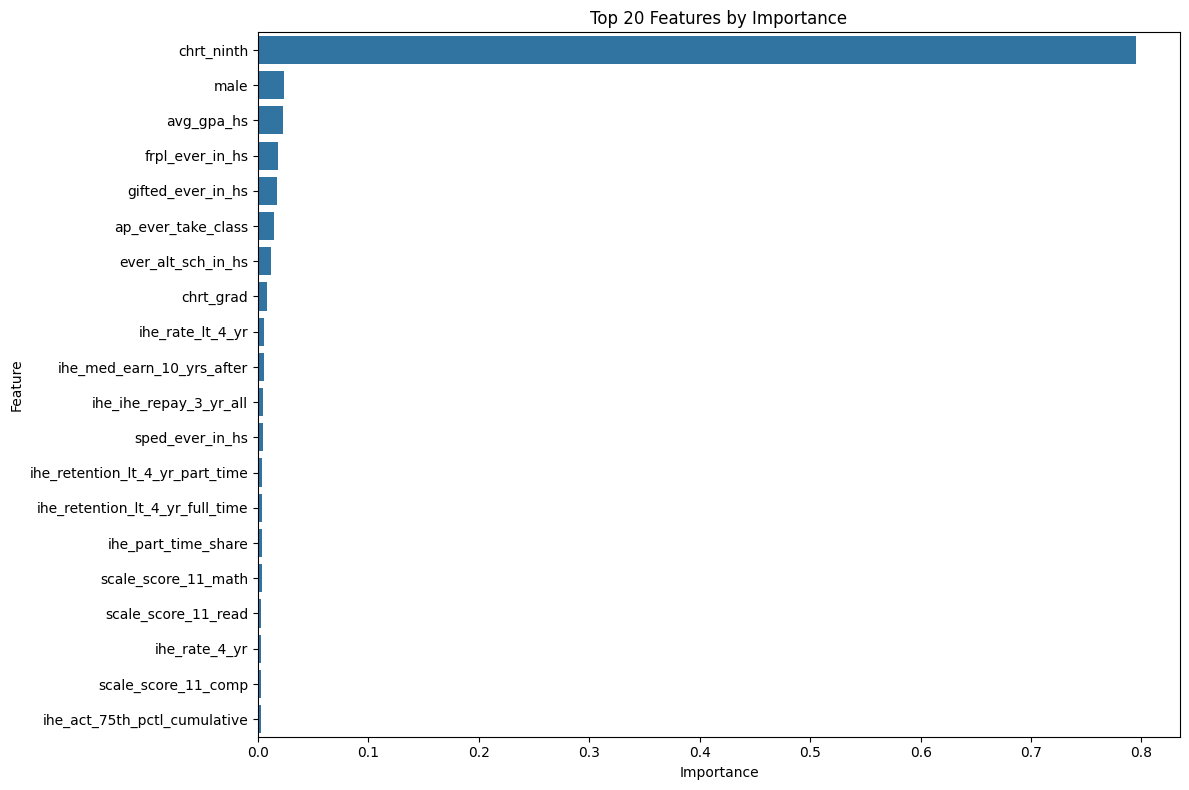

In [90]:

plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(20), x='Importance', y='Feature')
plt.title('Top 20 Features by Importance')
plt.tight_layout()
plt.show()

 Create an output directory in the user's home directory and save the feature importance to a CSV file.


In [91]:
import os

# Define output directory in a location where you have write permissions
# Using the user's home directory which should be writable
home_dir = os.path.expanduser("~")
output_dir = os.path.join(home_dir, "retention_model_outputs")

# Create the directory if it doesn't exist
try:
    os.makedirs(output_dir, exist_ok=True)
    print(f"Output directory created: {output_dir}")
except Exception as e:
    print(f"Error creating output directory: {e}")

# Save feature importance
feature_importance_path = os.path.join(output_dir, "retention_feature_importance.csv")
try:
    feature_importance.to_csv(feature_importance_path, index=False)
    print(f"Feature importance saved to: {feature_importance_path}")
except Exception as e:
    print(f"Error saving feature importance: {e}")
    # If saving fails, display the top 20 features instead
    print("\nTop 20 Features by Importance:")
    print(feature_importance.head(20))

Output directory created: /root/retention_model_outputs
Feature importance saved to: /root/retention_model_outputs/retention_feature_importance.csv


Perform SHAP analysis to explain model predictions and visualize feature importance if SHAP is installed.


/tmp/ipykernel_8214/934009189.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)


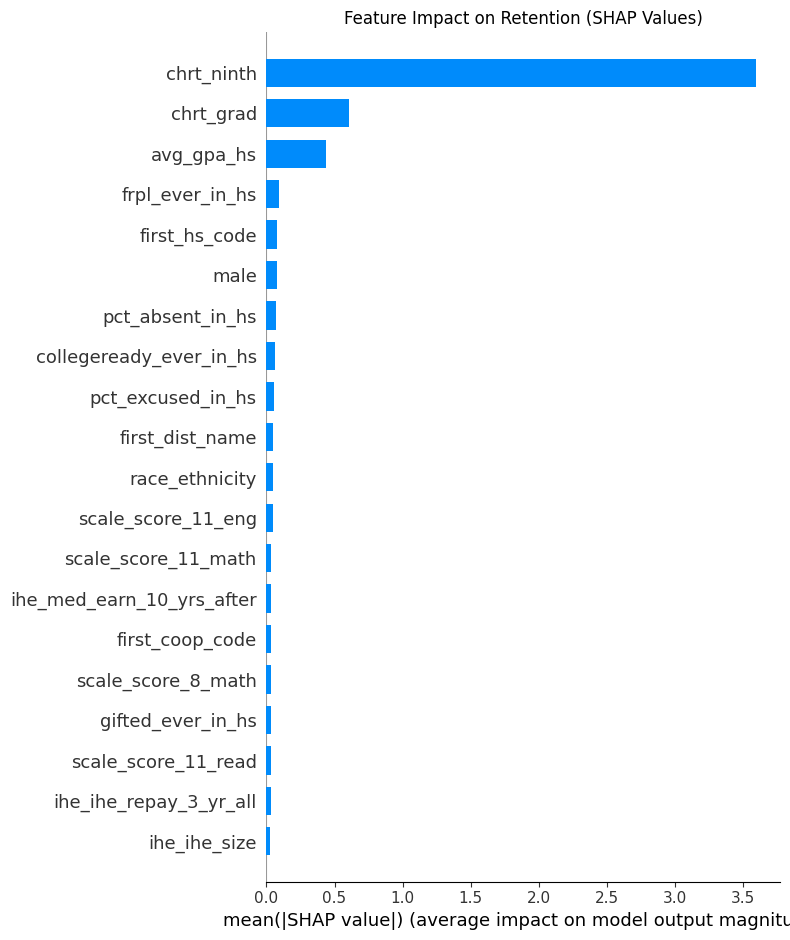

/tmp/ipykernel_8214/934009189.py:21: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sample, show=False)


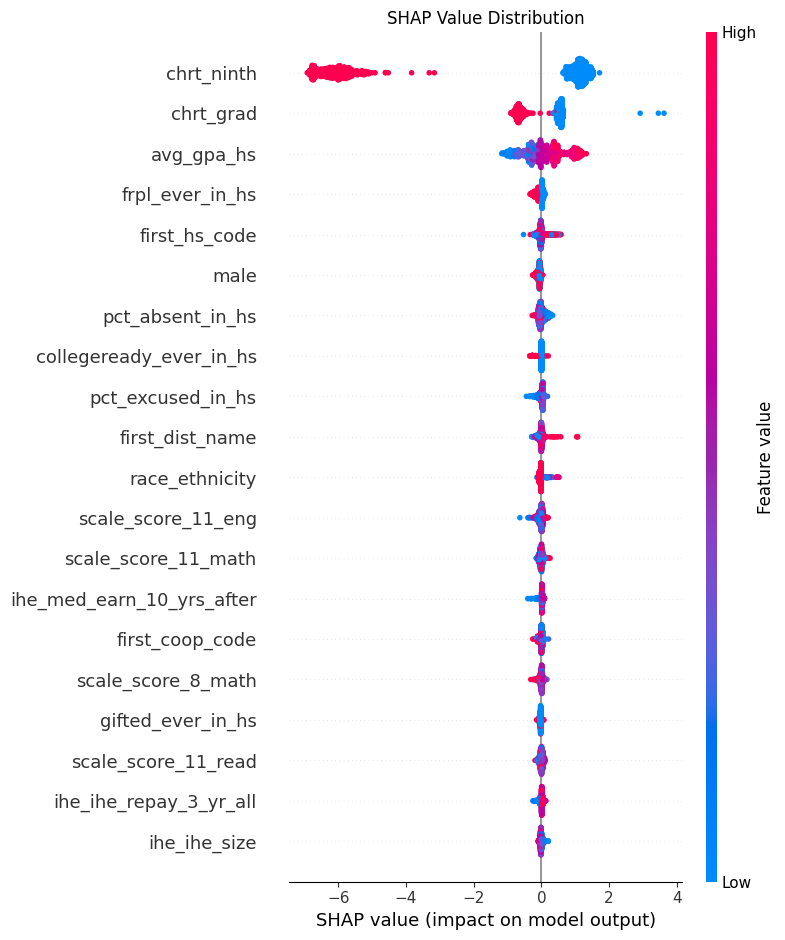

In [92]:
try:
    import shap

    # Create explainer
    explainer = shap.TreeExplainer(model)

    # Calculate SHAP values (on a sample of 1000 observations for speed)
    sample_size = min(1000, X_test.shape[0])
    X_sample = X_test.sample(sample_size, random_state=SEED)
    shap_values = explainer.shap_values(X_sample)

    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title('Feature Impact on Retention (SHAP Values)')
    plt.tight_layout()
    plt.show()

    # Detailed SHAP plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.title('SHAP Value Distribution')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("SHAP not available. Using standard feature importance instead.")


Optimize classification threshold by calculating metrics (F1, Precision, Recall, Accuracy) for various thresholds.


In [93]:

thresholds = np.linspace(0, 1, 100)
f1_scores = []
precision_scores = []
recall_scores = []
accuracy_scores = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    # Calculate metrics
    f1_scores.append(f1_score(y_test, y_pred_threshold))
    precision_scores.append(precision_score(y_test, y_pred_threshold))
    recall_scores.append(recall_score(y_test, y_pred_threshold))
    accuracy_scores.append(accuracy_score(y_test, y_pred_threshold))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Visualize the performance metrics (F1, Precision, Recall, Accuracy) against different classification thresholds.


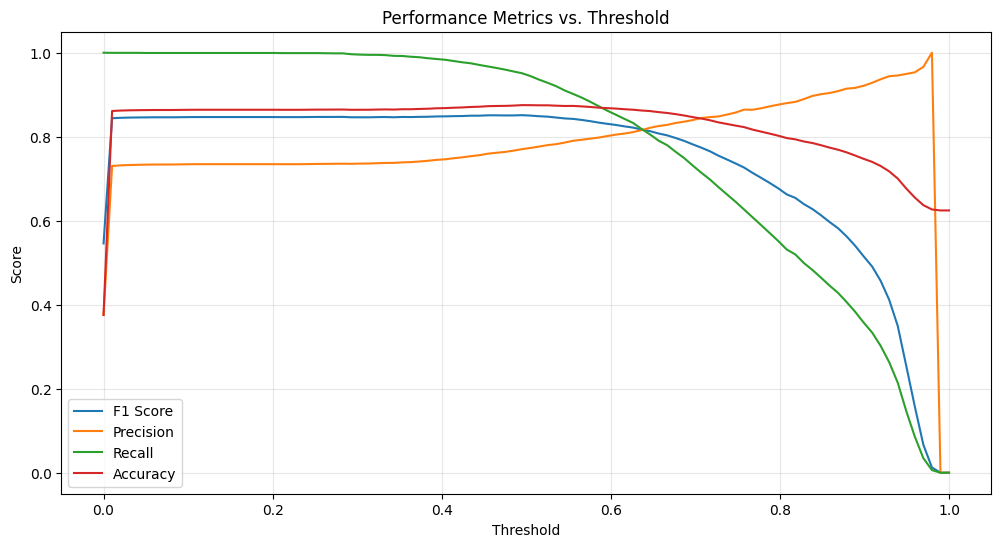

In [94]:

plt.figure(figsize=(12, 6))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.plot(thresholds, precision_scores, label='Precision')
plt.plot(thresholds, recall_scores, label='Recall')
plt.plot(thresholds, accuracy_scores, label='Accuracy')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Performance Metrics vs. Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Identify the optimal classification threshold based on the highest F1 score and display it.


In [95]:

optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold for F1 score: {optimal_threshold:.4f}")
print(f"F1 score at optimal threshold: {f1_scores[optimal_idx]:.4f}")

Optimal threshold for F1 score: 0.4949
F1 score at optimal threshold: 0.8513


Apply the optimal threshold to predictions and display the classification report with updated metrics.


In [96]:

y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)
print("Classification Report with Optimal Threshold:")
print(classification_report(y_test, y_pred_optimal))

Classification Report with Optimal Threshold:
              precision    recall  f1-score   support

         0.0       0.97      0.83      0.89      5551
         1.0       0.77      0.95      0.85      3338

    accuracy                           0.88      8889
   macro avg       0.87      0.89      0.87      8889
weighted avg       0.89      0.88      0.88      8889



Plot the confusion matrix using the predictions based on the optimal threshold.


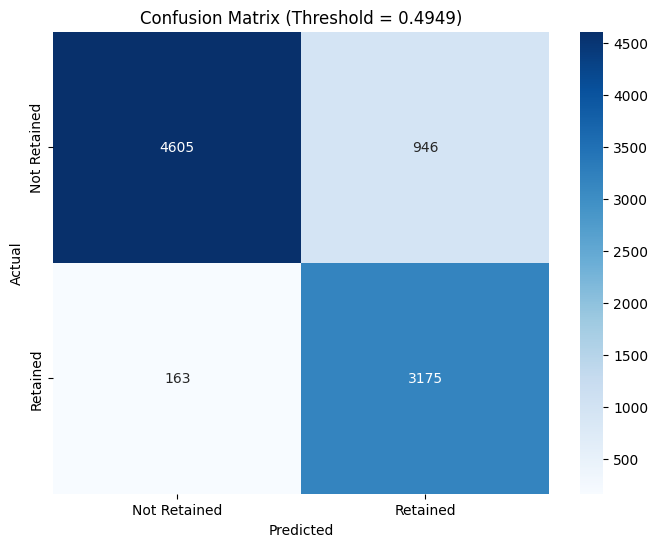

In [97]:

plt.figure(figsize=(8, 6))
cm_optimal = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues',
           xticklabels=['Not Retained', 'Retained'],
           yticklabels=['Not Retained', 'Retained'])
plt.title(f'Confusion Matrix (Threshold = {optimal_threshold:.4f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Assign risk groups based on predicted probabilities, categorizing as High, Medium, or Low Risk.


In [98]:

def assign_risk_group(prob):
    if prob < 0.3:
        return "High Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "Low Risk"

# Create risk groups
test_results = pd.DataFrame({
    'actual': y_test.values,
    'predicted_prob': y_pred_proba,
    'predicted': y_pred
})
test_results['risk_group'] = test_results['predicted_prob'].apply(assign_risk_group)

Analyze and display the actual and predicted retention rates for each risk group.


In [99]:

risk_group_analysis = test_results.groupby('risk_group').agg({
    'actual': ['count', 'mean'],
    'predicted': ['mean']
})
risk_group_analysis.columns = ['count', 'actual_retention_rate', 'predicted_retention_rate']
risk_group_analysis = risk_group_analysis.sort_values('actual_retention_rate')

print("Risk Group Analysis:")
print(risk_group_analysis)

Risk Group Analysis:
             count  actual_retention_rate  predicted_retention_rate
risk_group                                                         
High Risk     4373               0.003430                  0.000000
Medium Risk   1638               0.550672                  0.745421
Low Risk      2878               0.841209                  1.000000


Visualize the distribution of actual retention outcomes for each risk group using a count plot.


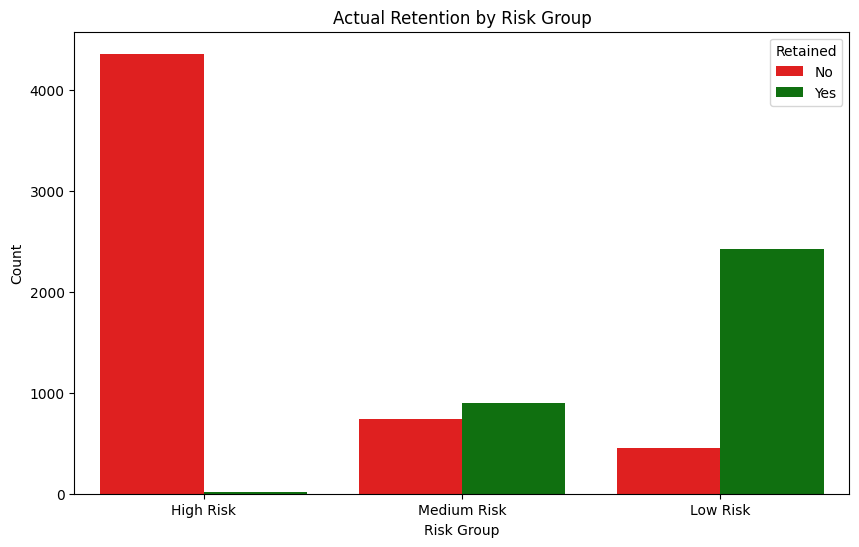

In [100]:

plt.figure(figsize=(10, 6))
sns.countplot(x='risk_group', hue='actual', data=test_results,
              palette=['red', 'green'], order=['High Risk', 'Medium Risk', 'Low Risk'])
plt.title('Actual Retention by Risk Group')
plt.xlabel('Risk Group')
plt.ylabel('Count')
plt.legend(title='Retained', labels=['No', 'Yes'])
plt.show()

Plot the actual retention rate for each risk group as a bar chart, with values annotated above each bar.


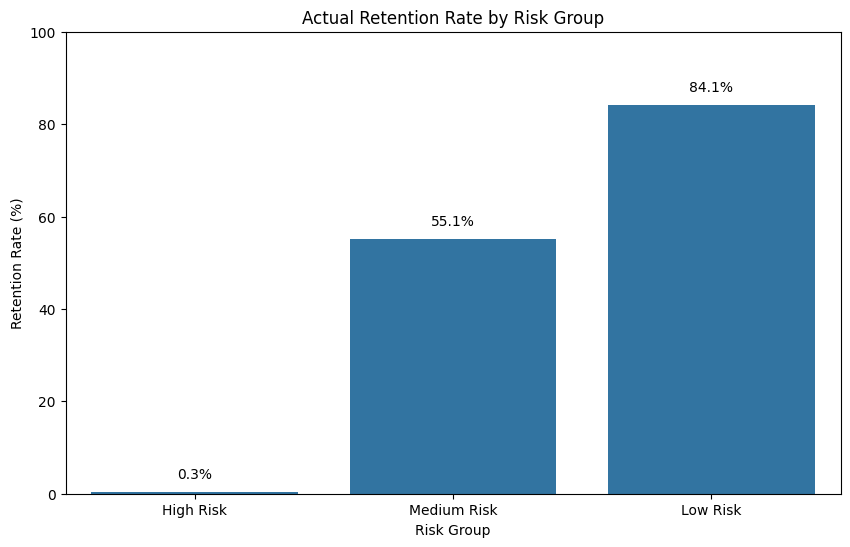

In [101]:

plt.figure(figsize=(10, 6))
risk_rates = test_results.groupby('risk_group')['actual'].mean() * 100
risk_rates = risk_rates.reindex(['High Risk', 'Medium Risk', 'Low Risk'])
sns.barplot(x=risk_rates.index, y=risk_rates.values)
plt.title('Actual Retention Rate by Risk Group')
plt.xlabel('Risk Group')
plt.ylabel('Retention Rate (%)')
plt.ylim(0, 100)
for i, v in enumerate(risk_rates):
    plt.text(i, v + 3, f"{v:.1f}%", ha='center')
plt.show()


Save the trained model to a pickle file in the output directory for future use.


In [102]:
import pickle

# Save model to the output directory
model_path = os.path.join(output_dir, "retention_prediction_model.pkl")
try:
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Model saved to: {model_path}")
except Exception as e:
    print(f"Error saving model: {e}")

Model saved to: /root/retention_model_outputs/retention_prediction_model.pkl


Save the predicted results, including actual, predicted, and risk group information, to a CSV file for further analysis.


In [103]:
results_path = os.path.join(output_dir, "retention_predictions.csv")
try:
    test_results.to_csv(results_path, index=False)
    print(f"Predictions saved to: {results_path}")
except Exception as e:
    print(f"Error saving predictions: {e}")
    # If saving fails, display a summary of the results
    print("\nResults Summary:")
    print(test_results.describe())

Predictions saved to: /root/retention_model_outputs/retention_predictions.csv
